# Lavatube Finder

In [79]:
import pandas as pd
import pygmt
import xarray as xr
import os
import numpy as np
import json
from utils import *
from sklearn.cluster import DBSCAN
from data import *

PLOT_GLOBAL_MAP = True
PLOT_MAP = False
cache_file = "data/mars_relief_cache.nc"
region_file = "data/mars_relief_cache_region.json"


## Cave Catalog

In [80]:
cave_catalog = pd.read_csv("data/Mars_Extended_Cave_Catalog.csv")
cave_catalog

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
0,APC001,240.4585,-0.94678,APC,1,25,32.0,APC -- tiny ~25m,5845.516289
1,APC003,237.6960,-12.47266,APC,1,30,47.0,APC 40m small deep nochain--big smrp?,10500.439389
2,APC005,240.8867,-5.68445,APC,1,30,17.0,APC deep pair,10144.570834
3,APC006,240.9421,-1.61377,APC,1,40,38.0,APC small deep?,6446.123804
4,APC007,241.2993,-1.68555,APC,1,40,28.0,"APC, deep? ~40m",6610.563531
...,...,...,...,...,...,...,...,...,...
1057,CC0926,161.1272,9.64587,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2767.424452
1058,CC0927,141.3146,30.56317,irr,0,NaN,NaN,Irregular surface hole,-1519.403413
1059,CC0928,141.3121,30.58740,crk,0,NaN,NaN,Small ambiguous hole in fracture,-1559.675572
1060,CC0929,242.9741,-0.26598,sky,1,NaN,NaN,"pair of 60-m pits in flow, 1km apart",6403.049279


In [81]:
test = cave_catalog[
    (cave_catalog["TypeCode"] == "lat") &
    (cave_catalog["elevation"] < 2000) &
    (cave_catalog["Priority"] < 2)
]
test

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation
844,CC0713,161.1316,9.61115,lat,0,NaN,NaN,Large lateral overhang,-2976.493428
847,CC0716,161.1048,9.65024,lat,0,NaN,NaN,cliff wall fracture intersect,-2767.787985
849,CC0718,161.1275,9.64604,lat,0,NaN,NaN,cliff wall fracture intersect,-2766.826081
853,CC0722,161.1200,9.61913,lat,0,NaN,NaN,cliff wall fracture intersect,-2997.784141
854,CC0723,161.1192,9.61890,lat,0,NaN,NaN,cliff wall fracture intersect,-3004.216373
855,CC0724,161.1170,9.61935,lat,0,NaN,NaN,cliff wall fracture intersect,-3014.285472
856,CC0725,161.1184,9.61610,lat,0,NaN,NaN,Cliff wall lateral tube candidate,-3020.803278
858,CC0727,276.3057,44.09782,lat,0,NaN,NaN,Cliff wall lateral tube candidate,1157.697805
861,CC0730,161.5701,7.23542,lat,0,NaN,NaN,cliff wall fracture intersect,-2648.197993
863,CC0732,161.5248,7.27509,lat,0,NaN,NaN,Rim overhang lateral candidate,-2647.597280


## Thermal Analysis

In [82]:
thermal_analysis = pd.read_csv("data/09_global_thermal_analysis_results.csv")
thermal_analysis = thermal_analysis[
    ((thermal_analysis["Priority"] == 0) | (thermal_analysis["Priority"] == 1)) &
    (thermal_analysis["elevation"] < 2000) &
    ((thermal_analysis["TypeCode"] == "sky") | (thermal_analysis["TypeCode"] == "pit") | (thermal_analysis["TypeCode"] == "APC") | (thermal_analysis["TypeCode"] == "pin") | (thermal_analysis["TypeCode"] == "lat"))
]

thermal_analysis

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,APC_Diameter_numeric,elevation,APC_Depth_numeric,...,TI_surrounding_median,TI_surrounding_std,Delta_TI,Local_TI_zscore,valid_surrounding_pixels,thermal_status,pixel_row,pixel_col,raster_file,thermal_rank_score
2,APC109,139.3289,29.70285,APC,1,240,74.0,240.0,-2211.773890,74.0,...,804.164459,368.673807,259.881782,0.704910,1188,ok,176,11457,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.980556
6,CC0832,155.0078,11.40808,lat,0,NaN,NaN,NaN,-2343.509332,NaN,...,204.511841,84.956229,62.611187,0.736982,1188,ok,11020,20751,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.961806
10,CC0718,161.1275,9.64604,lat,0,NaN,NaN,NaN,-2766.826081,NaN,...,222.665771,73.042747,38.864009,0.532072,1188,ok,12065,24378,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.933333
14,APC106,139.1303,28.58124,APC,1,255,92.0,255.0,-1691.011359,92.0,...,597.863159,96.090309,21.204547,0.220673,1188,ok,841,11340,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.913542
69,APC130,122.0461,21.52222,APC,1,110,41.0,110.0,-3801.719962,41.0,...,149.713364,19.125052,0.665969,0.034822,1188,ok,5025,1213,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.649306
84,CC0865,289.3141,38.11926,pit,0,NaN,NaN,NaN,515.329422,NaN,...,123.977921,11.414055,1.845321,0.161671,1188,ok,12969,29231,THEMIS_TI_Mosaic_Quant_30N240E_100mpp.tif,0.606597
96,CC0901,39.1812,26.27903,pit,0,NaN,NaN,NaN,-2140.779305,NaN,...,136.273972,9.033081,0.127713,0.014138,1188,ok,2206,23224,THEMIS_TI_Mosaic_Quant_00N000E_100mpp.tif,0.580903
101,CC0727,276.3057,44.09782,lat,0,NaN,NaN,NaN,1157.697805,NaN,...,490.664093,102.075353,-33.612293,-0.329289,1188,ok,9426,21520,THEMIS_TI_Mosaic_Quant_30N240E_100mpp.tif,0.566319
102,CC0011,122.3054,21.50098,pit,0,NaN,NaN,NaN,-3805.974900,NaN,...,516.821564,77.396981,-31.614228,-0.408468,1188,ok,5038,1367,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.563542
104,CC0725,161.1184,9.61610,lat,0,NaN,NaN,NaN,-3020.803278,NaN,...,283.612289,108.290271,-30.355166,-0.280313,1188,ok,12083,24373,THEMIS_TI_Mosaic_Quant_00N120E_100mpp.tif,0.561806


## Exposed Ice

In [83]:
exposed_ice = pd.read_csv("data/impact_exposed_ice.csv")
exposed_ice

,site_id,latitude,longitude,ice_exposure,d_icy,d_nonicy,reference,crism_ice,notes,color,image
0,Site P2,47.72,225.13,Possible,x,7.75,ESP_026248_2280,x,Ring-shaped color anomaly. Never strong and no...,#FFAA00,https://www.uahirise.org/ESP_026248_2280
1,Site P3,40.12,157.93,Possible,x,8,ESP_026989_2205,x,Relatively-blue crater wall became less distin...,#FFAA00,https://www.uahirise.org/ESP_026989_2205
2,Site P4,53.58,228.30,Possible,x,6,ESP_034186_2340,x,Crater with an anomalously bright illuminated ...,#FFAA00,https://www.uahirise.org/ESP_034186_2340
3,Site P7,57.24,358.02,Probable,x,1.75,ESP_037069_2375,x,One 1.5-m crater has an anomalous relatively-b...,#FFFF00,https://www.uahirise.org/ESP_037069_2375
4,Site P9,75.42,57.24,Probable,x,Uncertain,ESP_044992_2555,x,Multiple follow-on images show widespread brig...,#FFFF00,https://www.uahirise.org/ESP_044992_2555
...,...,...,...,...,...,...,...,...,...,...,...
66,Site 43,-71.74,156.63,Yes,4,x,ESP_058809_1080,x,Slightly relatively-yellow but setting highly ...,#00FFC5,https://www.uahirise.org/ESP_058809_1080
67,Site 45,52.95,50.87,Yes,7,x,ESP_033942_2335,n,x,#00FFC5,https://www.uahirise.org/ESP_033942_2335
68,Site 46,46.62,171.88,Yes,6,4,ESP_036443_2270 and ESP_036588_2270,x,x,#00FFC5,https://www.uahirise.org/ESP_036443_2270
69,Site 47,39.56,202.42,Yes,5.5,x,ESP_043853_2200,x,x,#00FFC5,https://www.uahirise.org/ESP_043853_2200


## Landing Sites

In [84]:
landing_sites = pd.read_csv("data/landing_sites.csv")
landing_sites

,longitude,latitude,mission
0,137.441700,-4.589500,MSL
1,135.623447,4.502000,InSight
2,-5.526600,-1.946000,Opportunity
3,175.478480,-14.572000,Spirit
4,-33.550000,19.330000,Pathfinder
5,-125.749222,68.219000,Phoenix
6,134.280900,47.667300,Viking 2
7,-47.950000,22.270000,Viking 1
8,77.450886,18.444627,M2020
9,110.318000,24.748000,Tianwen-1


## Priority Zones
Due to presence of subsurface ice

In [85]:
mars_radar_targeting_zones = pd.read_json("data/mars_radar_targeting_zones.json")
mars_radar_targeting_zones

,shape_length,shape_area,coordinates
0,5.843385e+07,21416293727900,"[[-179.999448, 36.251544], [-179.977833, 36.27..."
1,5.843385e+07,21416293727900,"[[-41.323617, -61.089205], [-43.348089, -61.08..."
2,5.843385e+07,21416293727900,"[[82.273909, -23.878042999999998], [84.553531,..."
3,5.843385e+07,21416293727900,"[[179.99954, 22.755546], [179.941932, 22.71595..."


## Regions of Interest

In [86]:
regions_to_avoid = pd.read_json("data/regions_to_avoid.json")
regions_to_avoid

,name,coordinates,reason
0,Cerberus Fossae,"[[16.16, 154.43], [16.16, 174.72], [6.23, 174....",high seismic activity
1,Tharsis Region,"[[42.27, 202.88], [42.27, 317.12], [-42.27, 31...",high seismic activity


In [87]:
points_of_interest = pd.read_json("data/points_of_interest.json")

# compute boundaries of interesting region
min_long = points_of_interest["Longitude"].min()
min_lat = points_of_interest["Latitude"].min()
max_long = points_of_interest["Longitude"].max()
max_lat = points_of_interest["Latitude"].max()
polygon_of_interest = [[min_lat, min_long], [min_lat, max_long], [max_lat, max_long], [max_lat, min_long]]

points_of_interest

,Landing Site,Longitude,Latitude,source
0,Huygens Crater,27,-13.5,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
1,Phlegra Dorsa,1,39.0,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
2,Southern Nectaris Fossae,2,-29.0,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
3,Gale Crater,3,-4.5,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
4,Endeavour Crater,43,-3.0,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
5,Eastern Valles Marineris,41,-4.0,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
6,Meridiani Planum,4,0.5,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
7,Hebrus Valles,5,20.0,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
8,Chryse – Viking,22,22.5,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...
9,Mesopotamia,28,-35.5,https://ieeexplore.ieee.org/stamp/stamp.jsp?tp...


In [88]:
regions_of_interest = pd.read_json("data/regions_of_interest.json")
regions_of_interest

,name,coordinates,comment
0,Arcadia Planitia,"[[64.2, 165.9], [64.2, 210.4], [33.9, 210.4], ...","relatively accessible water ice, broad, flat t..."
1,Utopia Planitia,"[[50.0, 80.0], [50.0, 115.0], [35.0, 115.0], [...","relatively accessible water ice, broad, flat t..."
2,Arabia terra,"[[45.36, -29.69], [45.36, 49.44], [-18.07, 49....","relatively accessible water ice, broad, flat t..."
3,Acidalia planitia,"[[68.68, 305.12], [68.68, 16.18], [14.75, 16.1...","relatively accessible water ice, broad, flat t..."
4,Elysium Planitia,"[[28.34, 125.93], [28.34, 183.55], [-22.38, 18...",favorable low-altitude terrain and a scientifi...


In [89]:
import numpy as np
import pandas as pd

# --- Configurazione ---
MARS_RADIUS_KM = 3389.5  # Raggio medio di Marte in km

def wrap_to_360(lon):
    """Garantisce che le longitudini siano nell'intervallo [0, 360] gradi."""
    return lon % 360

def exact_bbox_area_km2(coords):
    """
    Calcola l'area ESATTA su una sfera per una lista di punti [lat, lon].
    """
    lats = [pt[0] for pt in coords]
    lons = [wrap_to_360(pt[1]) for pt in coords]

    min_lat, max_lat = min(lats), max(lats)
    min_lon, max_lon = min(lons), max(lons)

    # Delta lat/lon
    dlat_deg = max_lat - min_lat
    dlon_deg = (max_lon - min_lon) % 360

    # Integrazione sferica per l'area: A = R^2 * dlon_rad * (sin(lat_max) - sin(lat_min))
    lat1_rad = np.radians(min_lat)
    lat2_rad = np.radians(max_lat)
    dlon_rad = np.radians(dlon_deg)

    area_km2 = (MARS_RADIUS_KM**2) * dlon_rad * (np.sin(lat2_rad) - np.sin(lat1_rad))
    area_deg2 = dlat_deg * dlon_deg

    return area_deg2, area_km2, (min_lat, max_lat, min_lon, max_lon)

# --- 1. Estrazione Coordinate ---
elysium_match = regions_of_interest[regions_of_interest["name"].str.lower() == "elysium planitia"]
tharsis_match = regions_to_avoid[regions_to_avoid["name"].str.lower() == "tharsis region"]

elysium_coords = elysium_match["coordinates"].iloc[0]
tharsis_coords = tharsis_match["coordinates"].iloc[0]

# --- 2. Calcolo Aree ed Estremi Bounding Box ---
elysium_deg2, elysium_km2, (el_min_lat, el_max_lat, el_min_lon, el_max_lon) = exact_bbox_area_km2(elysium_coords)
tharsis_deg2, tharsis_km2, (th_min_lat, th_max_lat, th_min_lon, th_max_lon) = exact_bbox_area_km2(tharsis_coords)

# --- 3. Normalizzazione Catalogo Cave ---
cave_catalog["longitude_360"] = wrap_to_360(cave_catalog["longitude"])

# --- 4. Filtro Diretto (senza Shapely) ---
cave_catalog["in_elysium"] = (
    cave_catalog["latitude"].between(el_min_lat, el_max_lat) &
    cave_catalog["longitude_360"].between(el_min_lon, el_max_lon)
)

cave_catalog["in_tharsis"] = (
    cave_catalog["latitude"].between(th_min_lat, th_max_lat) &
    cave_catalog["longitude_360"].between(th_min_lon, th_max_lon)
)

# --- 5. Stampa Risultati ---
print("=== ELYSIUM PLANITIA ===")
print(f"BBox Lat: [{el_min_lat:.2f}, {el_max_lat:.2f}] | Lon: [{el_min_lon:.2f}, {el_max_lon:.2f}]")
print(f"Area: {elysium_deg2:.2f} deg²  (~{elysium_km2:,.0f} km²)")
print(f"Candidati/Caves trovati: {cave_catalog['in_elysium'].sum()}")

print("\n=== THARSIS REGION ===")
print(f"BBox Lat: [{th_min_lat:.2f}, {th_max_lat:.2f}] | Lon: [{th_min_lon:.2f}, {th_max_lon:.2f}]")
print(f"Area: {tharsis_deg2:.2f} deg²  (~{tharsis_km2:,.0f} km²)")
print(f"Candidati/Caves trovati: {cave_catalog['in_tharsis'].sum()}")

=== ELYSIUM PLANITIA ===
BBox Lat: [-22.38, 28.34] | Lon: [125.93, 183.55]
Area: 2922.49 deg²  (~9,883,636 km²)
Candidati/Caves trovati: 85

=== THARSIS REGION ===
BBox Lat: [-42.27, 42.27] | Lon: [202.88, 317.12]
Area: 9657.85 deg²  (~30,815,551 km²)
Candidati/Caves trovati: 894


## Plot

In [74]:
# 1. Prepare coordinates for a 0-centered plot (shift 180–360 → -180–0)
cave_catalog["lon_plot"] = cave_catalog["longitude"].apply(
    lambda x: x if x <= 180 else x - 360
)

landing_sites["lon_plot"] = landing_sites["longitude"].apply(
    lambda x: x if x <= 180 else x - 360
)

exposed_ice["lon_plot"] = exposed_ice["longitude"].apply(
    lambda x: x if x <= 180 else x - 360
)

# Apply coordinate shift to the new Regions of Interest
points_of_interest["lon_plot"] = points_of_interest["Longitude"].apply(
    lambda x: x if x <= 180 else x - 360
)

# 2. Update data_region to include the new points
data_region = [
    max(min(cave_catalog.lon_plot.min(), landing_sites.lon_plot.min(), points_of_interest.lon_plot.min()) - 2, -180),
    min(max(cave_catalog.lon_plot.max(), landing_sites.lon_plot.max(), points_of_interest.lon_plot.max()) + 2, 180),
    max(min(cave_catalog.latitude.min(), landing_sites.latitude.min(), points_of_interest.Latitude.min()) - 2, -90),
    min(max(cave_catalog.latitude.max(), landing_sites.latitude.max(), points_of_interest.Latitude.max()) + 2, 90),
]

loading cached data


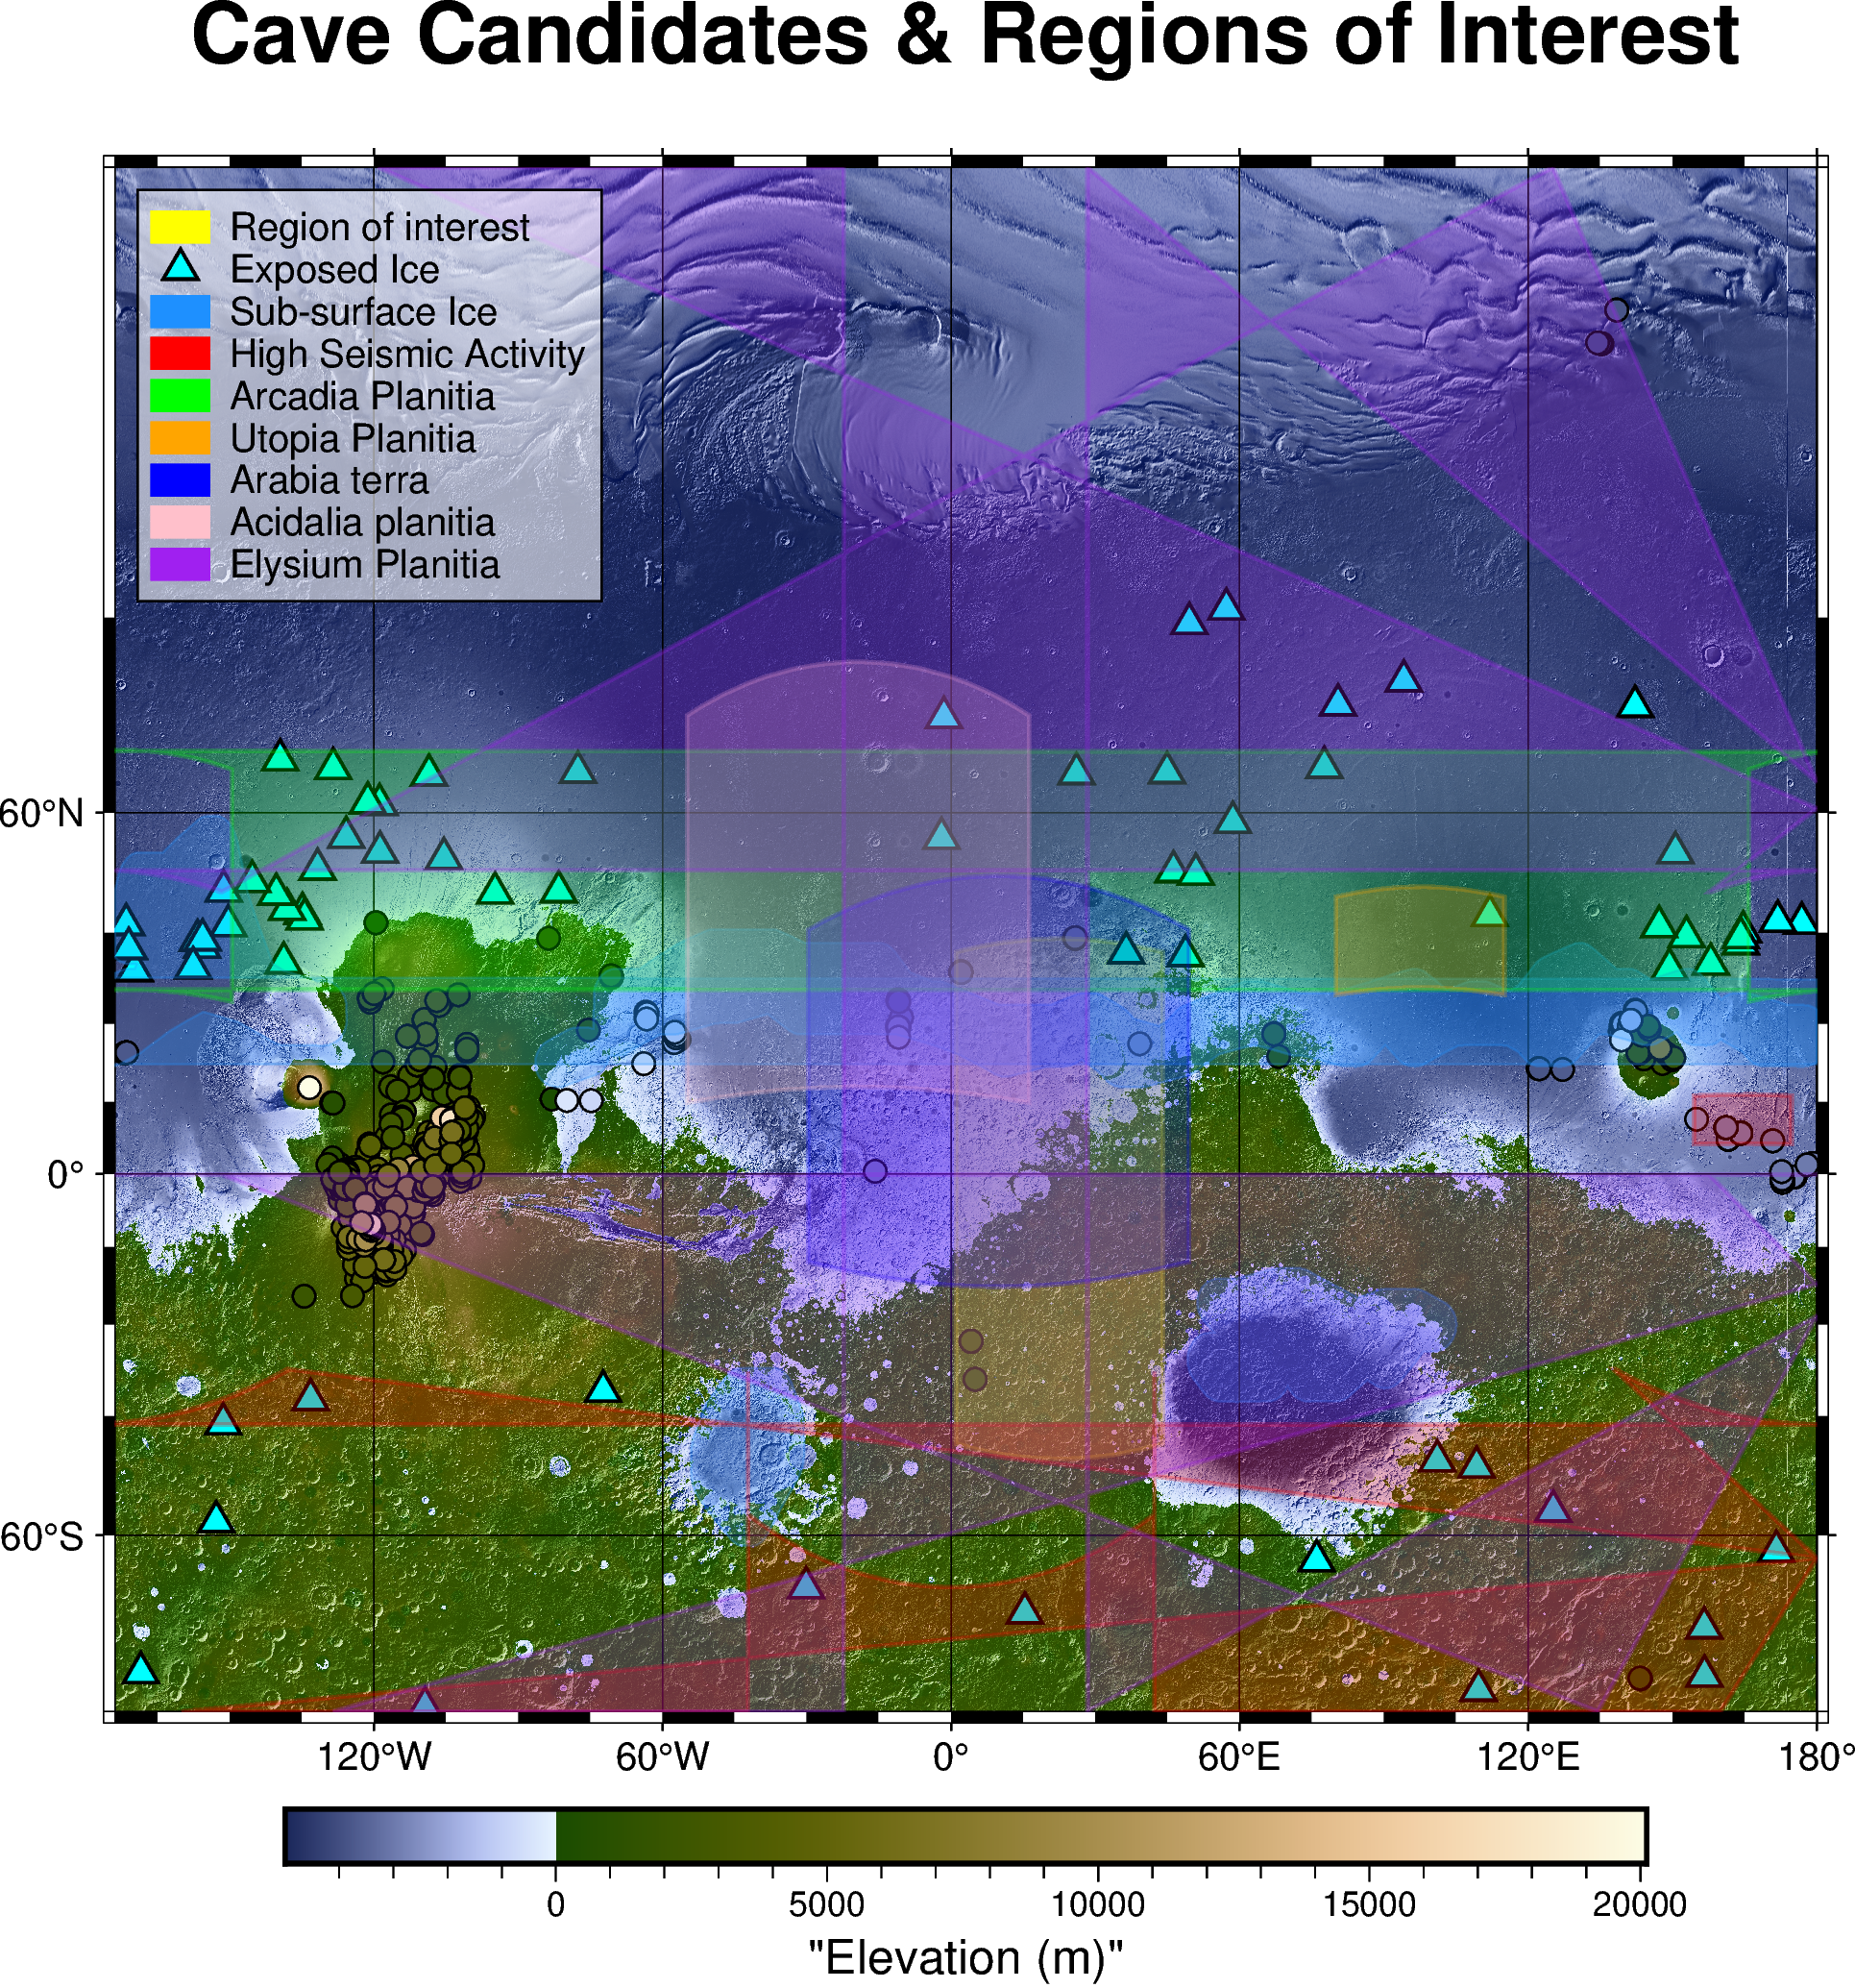

In [75]:
if PLOT_GLOBAL_MAP:
    # 3. Load background relief
    if os.path.exists(cache_file) and not region_changed(data_region, region_file):
        print("loading cached data")
        grid = xr.load_dataarray(cache_file, engine="netcdf4")
    else:
        print("Downloading data")
        grid = pygmt.datasets.load_mars_relief(resolution="01m", region=data_region)
        grid.to_netcdf(cache_file, engine="netcdf4")
        with open(region_file, "w") as f:
            json.dump(data_region, f)

    # 4. Initialize the Figure
    fig = pygmt.Figure()

    # Color palette for cave elevation
    pygmt.makecpt(
        cmap="oleron",
        series=[cave_catalog.elevation.min(), cave_catalog.elevation.max()]
    )

    # 5. Plot the background terrain
    fig.grdimage(
        grid=grid,
        region=data_region,
        projection="M0/15c",
        shading=True,
        frame=["afg", "WSne+tCave Candidates & Regions of Interest"]
    )

    # 6. Plot the lava tubes
    fig.plot(
        x=cave_catalog.lon_plot,
        y=cave_catalog.latitude,
        fill=cave_catalog.elevation,
        cmap=True,
        style="c0.2c",
        pen="0.5p,black",
    )

    # 7. Plot landing sites (existing)
    lats = [c[0] for c in polygon_of_interest]
    lons = [c[1] if c[1] <= 180 else c[1] - 360 for c in polygon_of_interest]

    fig.plot(
        x=lons,
        y=lats,
        fill="yellow",
        pen="1p,yellow",
        transparency=75,
        close=True,
        label="Region of interest",
    )

    # Plot surface ice position
    fig.plot(
        x=exposed_ice.lon_plot,
        y=exposed_ice.latitude,
        style="t0.35c",   # triangles
        fill="cyan",
        pen="0.8p,black",
        label="Exposed Ice",
    )

    # plot sub-surface ice position
    for i, row in mars_radar_targeting_zones.iterrows():
        coords = row["coordinates"]
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]

        fig.plot(
            x=lons,
            y=lats,
            fill="dodgerblue",
            pen="0.5p,dodgerblue",
            transparency=75,
            close=True,
            label="Sub-surface Ice" if i == 0 else None,
        )

    # plot regions to avoid
    for i, row in regions_to_avoid.iterrows():
        coords = row["coordinates"]

        lats = [c[0] for c in coords]
        lons = [c[1] if c[1] <= 180 else c[1] - 360 for c in coords]

        fig.plot(
            x=lons,
            y=lats,
            fill="red",
            pen="1p,red",
            transparency=75,
            close=True,
            label="High Seismic Activity" if i == 0 else None,
        )

    # plot regions of interest
    colors = ["green", "orange", "blue", "pink", "purple"]
    for i, row in regions_of_interest.iterrows():
        coords = row["coordinates"]

        lats = [c[0] for c in coords]
        lons = [c[1] if c[1] <= 180 else c[1] - 360 for c in coords]

        fig.plot(
            x=lons,
            y=lats,
            fill=colors[i],
            pen=f"1p,{colors[i]}",
            transparency=75,
            close=True,
            label=row["name"],
        )

    # 8. Add legend
    fig.legend(
        position="JTL+jTL+o0.2c",
        box="+gwhite@40+p0.5p,black"
    )

    # 9. Add colorbar for cave elevation and display
    fig.colorbar(frame='af+l"Elevation (m)"')
    fig.show()

## Lavatube Selection

Selection criteria:
- *Low altitude*. To better exploit the air drag during landing. To be better protected from radiation by the atmosphere above.
- *Closeness to ice deposits*.
- *Suitable landing location*. There must be enough flat terrain for landing relatively close to the lavatubes.
- *Current knowledge*. Priority is given to those candidates that are already been clearly observed, for which pictures have already been taken.
- *Thermal Profile*.

In [40]:
# 1. Extract coordinates safely
arabia_coord = regions_of_interest[regions_of_interest["name"] == "Arabia terra"]["coordinates"].iloc[0]
acidalia_coord = regions_of_interest[regions_of_interest["name"] == "Acidalia planitia"]["coordinates"].iloc[0]
elysium_coord = regions_of_interest[regions_of_interest["name"] == "Elysium Planitia"]["coordinates"].iloc[0]

# 2. Create boolean masks for each region
in_arabia = cave_catalog.apply(lambda r: is_point_in_region(r["latitude"], r["longitude"], arabia_coord), axis=1)
in_acidalia = cave_catalog.apply(lambda r: is_point_in_region(r["latitude"], r["longitude"], acidalia_coord), axis=1)
in_elysium = cave_catalog.apply(lambda r: is_point_in_region(r["latitude"], r["longitude"], elysium_coord), axis=1)

# 3. Filter into a new DataFrame (.copy() prevents Slice Warnings later)
filtered_cave_df = cave_catalog[in_arabia | in_acidalia | in_elysium].copy()
filtered_cave_df = filtered_cave_df[(filtered_cave_df['Priority'] == 0) | (filtered_cave_df['Priority'] == 1)]
filtered_cave_df

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation,lon_plot
103,APC112,147.5129,24.76074,APC,1,100,72.0,Good Elysium Type II APC,8914.272626,147.5129
104,APC113,147.9082,22.53269,APC,1,270,98.0,Elysium APC,2388.781760,147.9082
105,APC114,148.7321,24.41968,APC,1,90,20.0,~90m - maybe TypeII,4066.266486,148.7321
106,APC115,149.9153,23.21488,APC,1,135,74.0,Classic APC ~145m,2037.409658,149.9153
403,CC0272,348.9619,34.21344,sky,0,NaN,NaN,Tube?,-4685.077564,-11.0381
...,...,...,...,...,...,...,...,...,...,...
1053,CC0922,161.1185,9.64691,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2771.917849,161.1185
1054,CC0923,161.1217,9.64615,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2771.422250,161.1217
1055,CC0924,161.1229,9.64621,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2769.863844,161.1229
1056,CC0925,161.1371,9.64560,crk,0,NaN,NaN,Cerberus fractures in HiRISE,-2773.076374,161.1371


In [41]:
filtered_cave_df = filtered_cave_df[
    (filtered_cave_df["TypeCode"] == "sky") | (filtered_cave_df["TypeCode"] == "pit") | (filtered_cave_df["TypeCode"] == "APC") | (filtered_cave_df["TypeCode"] == "pin") | (filtered_cave_df["TypeCode"] == "lat")
]
filtered_cave_df

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation,lon_plot
103,APC112,147.5129,24.76074,APC,1,100,72.0,Good Elysium Type II APC,8914.272626,147.5129
104,APC113,147.9082,22.53269,APC,1,270,98.0,Elysium APC,2388.781760,147.9082
105,APC114,148.7321,24.41968,APC,1,90,20.0,~90m - maybe TypeII,4066.266486,148.7321
106,APC115,149.9153,23.21488,APC,1,135,74.0,Classic APC ~145m,2037.409658,149.9153
403,CC0272,348.9619,34.21344,sky,0,NaN,NaN,Tube?,-4685.077564,-11.0381
844,CC0713,161.1316,9.61115,lat,0,NaN,NaN,Large lateral overhang,-2976.493428,161.1316
847,CC0716,161.1048,9.65024,lat,0,NaN,NaN,cliff wall fracture intersect,-2767.787985,161.1048
849,CC0718,161.1275,9.64604,lat,0,NaN,NaN,cliff wall fracture intersect,-2766.826081,161.1275
853,CC0722,161.1200,9.61913,lat,0,NaN,NaN,cliff wall fracture intersect,-2997.784141,161.1200
854,CC0723,161.1192,9.61890,lat,0,NaN,NaN,cliff wall fracture intersect,-3004.216373,161.1192


In [42]:
# We only select lavatubes with Priority 0 OR 1, that are at an elevation < 2000m and have a skylight
print(f"Cave catalog before filtering contains {len(cave_catalog)} entries")
cave_catalog = cave_catalog[
    ((cave_catalog["Priority"] == 0) | (cave_catalog["Priority"] == 1)) &
    (cave_catalog["elevation"] < 2000) &
    ((cave_catalog["TypeCode"] == "sky") | (cave_catalog["TypeCode"] == "pit") | (cave_catalog["TypeCode"] == "APC") | (cave_catalog["TypeCode"] == "pin") | (cave_catalog["TypeCode"] == "lat"))
]
print(f"Cave catalog after filtering contains {len(cave_catalog)} entries")

# only select regions where ice is (at least) probably there
print(f"\n{len(exposed_ice)} surface ice locations before filtering")
exposed_ice = exposed_ice[(exposed_ice["ice_exposure"] == "Yes") | (exposed_ice["ice_exposure"] == "Probable")]
print(f"{len(exposed_ice)} surface ice locations after filtering")

Cave catalog before filtering contains 1062 entries
Cave catalog after filtering contains 28 entries

71 surface ice locations before filtering
52 surface ice locations after filtering


### DB-scan

In [43]:
# DBSCAN works in Euclidean space, so we use radians for haversine metric
coords_rad = np.radians(cave_catalog[['latitude', 'lon_plot']].values)

radiant_eps = 0.0001
martian_radius = 3389.5
print(f"Clusters are being searched in a radius of {radiant_eps * martian_radius:.2f}km")

db = DBSCAN(
    eps=radiant_eps,            # angular radius threshold in radians
    min_samples=2,              # minimum points to form a cluster core
    algorithm='ball_tree',
    metric='haversine'
).fit(coords_rad)

cave_catalog['cluster'] = db.labels_

n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
n_noise = (db.labels_ == -1).sum()

print(f"Clusters found: {n_clusters}")
print(f"Noise points (unclustered): {n_noise}")
print(cave_catalog['cluster'].value_counts())

Clusters are being searched in a radius of 0.34km
Clusters found: 3
Noise points (unclustered): 20
cluster
-1    20
 0     4
 1     2
 2     2
Name: count, dtype: int64


In [44]:
cave_catalog

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation,lon_plot,cluster
97,APC106,139.1303,28.58124,APC,1,255,92.0,sloped floor?,-1691.011359,139.1303,-1
98,APC107,139.7143,28.58714,APC,1,160,34.0,in chain - Elysium,-1121.154670,139.7143,-1
99,APC108,139.9279,28.53275,APC,1,360,105.0,in chain - Elysium 3+,-844.006300,139.9279,-1
100,APC109,139.3289,29.70285,APC,1,240,74.0,220x260ish,-2211.773890,139.3289,-1
101,APC110,139.6895,29.71901,APC,1,115,43.0,near trough rim -- Elysium,-2108.971707,139.6895,-1
102,APC111,142.1093,29.26669,APC,1,160,55.0,near Elysium ~160m,-221.777819,142.1093,-1
120,APC130,122.0461,21.52222,APC,1,110,41.0,collapse pit kinda like an APC,-3801.719962,122.0461,-1
142,CC0011,122.3054,21.50098,pit,0,NaN,NaN,large deep Hephaestus pit,-3805.974900,122.3054,-1
403,CC0272,348.9619,34.21344,sky,0,NaN,NaN,Tube?,-4685.077564,-11.0381,-1
844,CC0713,161.1316,9.61115,lat,0,NaN,NaN,Large lateral overhang,-2976.493428,161.1316,-1


In [20]:
best_thermal = ["APC106", "APC109", "CC0832", "CC0718"]

cave_catalog[cave_catalog["label"].isin(best_thermal)]

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation,lon_plot,cluster
97,APC106,139.1303,28.58124,APC,1,255,92.0,sloped floor?,-1691.011359,139.1303,-1
100,APC109,139.3289,29.70285,APC,1,240,74.0,220x260ish,-2211.773890,139.3289,-1
849,CC0718,161.1275,9.64604,lat,0,NaN,NaN,cliff wall fracture intersect,-2766.826081,161.1275,-1
963,CC0832,155.0078,11.40808,lat,0,NaN,NaN,Lateral fracture candidate in Cerberus Fossae,-2343.509332,155.0078,-1


In [21]:
clusters = cave_catalog[cave_catalog["cluster"] != -1]
clusters

,label,longitude,latitude,TypeCode,Priority,APC_Diameter,APC_Depth,Comment,elevation,lon_plot,cluster
853,CC0722,161.1200,9.61913,lat,0,NaN,NaN,cliff wall fracture intersect,-2997.784141,161.1200,0
854,CC0723,161.1192,9.61890,lat,0,NaN,NaN,cliff wall fracture intersect,-3004.216373,161.1192,0
855,CC0724,161.1170,9.61935,lat,0,NaN,NaN,cliff wall fracture intersect,-3014.285472,161.1170,0
856,CC0725,161.1184,9.61610,lat,0,NaN,NaN,Cliff wall lateral tube candidate,-3020.803278,161.1184,0
863,CC0732,161.5248,7.27509,lat,0,NaN,NaN,Rim overhang lateral candidate,-2647.597280,161.5248,1
864,CC0733,161.5213,7.27475,lat,0,NaN,NaN,Rim overhang lateral candidate,-2647.702569,161.5213,1
991,CC0860,240.4131,46.41468,lat,0,NaN,NaN,small channel wall lateral 6m,22.199550,-119.5869,2
992,CC0861,240.4133,46.41562,lat,0,NaN,NaN,small channel wall lateral 3m,21.804545,-119.5867,2


In [22]:
if PLOT_MAP:
    # 3. Load background relief
    if os.path.exists(cache_file) and not region_changed(data_region, region_file):
        print("loading cached data")
        grid = xr.load_dataarray(cache_file, engine="netcdf4")
    else:
        print("Downloading data")
        grid = pygmt.datasets.load_mars_relief(resolution="01m", region=data_region)
        grid.to_netcdf(cache_file, engine="netcdf4")
        with open(region_file, "w") as f:
            json.dump(data_region, f)

    # 4. Initialize the Figure
    fig = pygmt.Figure()

    # 5. Build CPT from terrain grid range (same palette as original plot)
    pygmt.makecpt(
        cmap="oleron",
        series=[float(grid.min()), float(grid.max())]
    )

    # 6. Plot the background terrain
    fig.grdimage(
        grid=grid,
        region=data_region,
        projection="M0/15c",
        shading=True,
        cmap=True,          # use the CPT we just made
        frame=["afg", "WSne+tCave Candidates - Clusters"]
    )

    # 7. Plot sub-surface ice polygons
    for i, row in mars_radar_targeting_zones.iterrows():
        coords = row["coordinates"]
        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]
        fig.plot(
            x=lons,
            y=lats,
            fill="dodgerblue",
            pen="0.5p,dodgerblue",
            transparency=75,
            close=True,
            label="Sub-surface Ice" if i == 0 else None,
        )

    # 8. Plot landing sites
    colors = ["red", "yellow", "cyan", "magenta", "orange", "white", "green"]
    missions = landing_sites['mission'].unique()
    for i, mission in enumerate(missions):
        subset = landing_sites[landing_sites['mission'] == mission]
        fig.plot(
            x=subset.lon_plot,
            y=subset.latitude,
            style="s0.35c",
            fill=colors[i % len(colors)],
            pen="0.8p,black",
            label=mission,
        )

    # 9. Plot exposed ice
    exposed_ice['lon_plot'] = exposed_ice['longitude'].apply(lambda x: x if x <= 180 else x - 360)
    fig.plot(
        x=exposed_ice.lon_plot,
        y=exposed_ice.latitude,
        style="t0.35c",
        fill="cyan",
        pen="0.8p,black",
        label="Exposed Ice",
    )

    # 10. Plot DBSCAN clusters (fixed colors, no CPT)
    cluster_colors = [
        "tomato", "orange", "gold", "limegreen", "deepskyblue",
        "orchid", "coral", "turquoise", "khaki", "slateblue",
    ]

    cluster_ids = sorted(cave_catalog['cluster'].unique())
    for cid in cluster_ids:
        subset = cave_catalog[cave_catalog['cluster'] == cid]
        if cid == -1:
            color, label = "gray", "Noise"
        else:
            color = cluster_colors[cid % len(cluster_colors)]
            label = f"Cluster {cid}"
        fig.plot(
            x=subset.lon_plot,
            y=subset.latitude,
            style="c0.2c",
            fill=color,
            pen="0.5p,black",
            label=label,
        )

    # 11. Add legend
    fig.legend(
        position="JTL+jTL+o0.2c",
        box="+gwhite@40+p0.5p,black"
    )

    # 12. Colorbar reflects terrain elevation
    fig.colorbar(frame='af+l"Elevation (m)"')
    fig.show()

In [23]:
if PLOT_MAP:
    if os.path.exists(cache_file) and not region_changed(data_region, region_file):
        grid = xr.load_dataarray(cache_file, engine="netcdf4")

    else:
        grid = pygmt.datasets.load_mars_relief(
            resolution="01m",
            region=data_region,
        )

        grid.to_netcdf(cache_file, engine="netcdf4")

        with open(region_file, "w") as f:
            json.dump(data_region, f)

    fig = pygmt.Figure()

    pygmt.makecpt(
        cmap="oleron",
        series=[float(grid.min()), float(grid.max())]
    )

    fig.grdimage(
        grid=grid,
        region=data_region,
        projection="M0/15c",
        shading=True,
        cmap=True,
        frame=[
            "afg",
            "WSne+tCave Candidates - Clusters"
        ],
    )

    for i, row in mars_radar_targeting_zones.iterrows():

        coords = row["coordinates"]

        lons = [c[0] for c in coords]
        lats = [c[1] for c in coords]

        fig.plot(
            x=lons,
            y=lats,
            fill="dodgerblue",
            pen="0.5p,dodgerblue",
            transparency=75,
            close=True,
            label="Sub-surface Ice" if i == 0 else None,
        )

    colors = [
        "red",
        "yellow",
        "cyan",
        "magenta",
        "orange",
        "white",
        "green",
    ]

    missions = landing_sites["mission"].unique()

    for i, mission in enumerate(missions):

        subset = landing_sites[
            landing_sites["mission"] == mission
        ]

        fig.plot(
            x=subset.lon_plot,
            y=subset.latitude,
            style="s0.35c",
            fill=colors[i % len(colors)],
            pen="0.8p,black",
            label=mission,
        )

    fig.plot(
        x=exposed_ice.lon_plot,
        y=exposed_ice.latitude,
        style="t0.35c",
        fill="cyan",
        pen="0.8p,black",
        label="Exposed Ice",
    )

    fig.legend(
        position="JTL+jTL+o0.2c",
        box="+gwhite@40+p0.5p,black",
    )

    cluster_colors = [
        "tomato",
        "orange",
        "gold",
        "limegreen",
        "deepskyblue",
        "orchid",
        "coral",
        "turquoise",
        "khaki",
        "slateblue",
    ]

    cluster_ids = sorted(
        cave_catalog["cluster"].unique()
    )

    for cid in cluster_ids:

        subset = cave_catalog[
            cave_catalog["cluster"] == cid
        ]

        if cid == -1:
            color = "gray"

        else:
            color = cluster_colors[
                cid % len(cluster_colors)
            ]

        fig.plot(
            x=subset.lon_plot,
            y=subset.latitude,
            style="c0.2c",
            fill=color,
            pen="0.5p,black",
        )

    for cid in cluster_ids:

        if cid == -1:
            continue

        subset = cave_catalog[
            cave_catalog["cluster"] == cid
        ]

        x = subset.lon_plot.values
        y = subset.latitude.values

        center_x = np.mean(x)
        center_y = np.mean(y)

        distances = np.sqrt(
            (x - center_x) ** 2 +
            (y - center_y) ** 2
        )

        radius = distances.max() + 0.3

        fig.plot(
            x=center_x,
            y=center_y,
            style=f"c{2 * radius}c",
            pen="1p,red,.",
        )

    cluster_legend_file = "cluster_legend.txt"

    with open(cluster_legend_file, "w") as f:

        f.write("H 12p,Helvetica-Bold Clusters\n")

        for cid in cluster_ids:

            if cid == -1:
                color = "gray"
                label = "Noise"

            else:
                color = cluster_colors[
                    cid % len(cluster_colors)
                ]
                label = f"Cluster {cid}"

            f.write(
                f"S 0.2c c 0.2c {color} "
                f"0.5p 0.4c {label}\n"
            )

    fig.legend(
        spec=cluster_legend_file,
        position="JTR+jTR+o0.2c",
        box="+gwhite@40+p0.5p,black",
    )

    fig.colorbar(
        frame='af+l"Elevation (m)"'
    )

    fig.show()

In [24]:
# 1. FILTRAGGIO: Solo Cluster 3 e 4
selected_caves = cave_catalog[cave_catalog["cluster"].isin([2, 3])].copy()

# 2. REGIONE: Calcolata solo sui tubi di lava (con margine di 2 gradi)
data_region = [
    max(selected_caves.lon_plot.min() - 2, -180),
    min(selected_caves.lon_plot.max() + 2,  180),
    max(selected_caves.latitude.min() - 2,  -90),
    min(selected_caves.latitude.max() + 2,   90),
]

if PLOT_MAP:
    # Gestione Cache Topografia
    if os.path.exists(cache_file) and not region_changed(data_region, region_file):
        grid = xr.load_dataarray(cache_file, engine="netcdf4")
    else:
        grid = pygmt.datasets.load_mars_relief(resolution="12s", region=data_region)
        grid.to_netcdf(cache_file, engine="netcdf4")
        with open(region_file, "w") as f:
            json.dump(data_region, f)

    fig = pygmt.Figure()

    # Scala colori basata sulle elevazioni locali
    pygmt.makecpt(cmap="oleron", series=[float(grid.min()), float(grid.max())])

    # Mappa base
    fig.grdimage(
        grid=grid,
        region=data_region,
        projection="M15c", # Proiezione Mercatore, larghezza 15cm
        shading=True,
        cmap=True,
        frame=["afg", "WSne+tLavatube Clusters in Arabia Terra crater"]
    )

    # Plot dei punti
    fig.plot(
        x=selected_caves.lon_plot,
        y=selected_caves.latitude,
        style="c0.25c",      # Cerchi da 0.25cm
        fill="tomato",
        pen="0.8p,black",
        label="Lavatube Candidates"
    )

    # Calcolo e plot del cerchio di contenimento
    x = selected_caves.lon_plot.values
    y = selected_caves.latitude.values
    center_x, center_y = np.mean(x), np.mean(y)
    radius = np.sqrt(((x - center_x)**2 + (y - center_y)**2)).max() + 0.3

    fig.plot(
        x=center_x,
        y=center_y,
        style=f"c{2 * radius}c",
        pen="1.5p,red,-." # Linea rossa spessa, tratto-punto
    )

    # Legenda semplice
    fig.legend(position="JTL+jTL+o0.2c", box="+gwhite@50+p0.5p,black")

    # Barra dell'elevazione
    fig.colorbar(frame='af+l"Elevation (m)"')

    fig.show()